# <span style="color:orange"> **NOTES** </span>
## <span style="color:yellow"> ***WEEK 2*** </span>
### <span style="color:red"> **Building Makemore Part 3** </span>
We try to improve the neural net by fixing our initialization, doing natch normalization and visualising things properly.

In [89]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import random
random.seed(42)
g=torch.Generator().manual_seed(2176)
import torch.nn.functional as F

In [90]:
words=open('names.txt','r').read().splitlines()

In [91]:
#encoding
itos={i+1:ch for i,ch in enumerate(list("abcdefghijklmnopqrstuvwxyz"))}
itos[0]='.'
stoi={ch:i for i,ch in itos.items()}

In [92]:
#hyperparameters
block_size=5
vector_dim=10
hidden_layer_size=200
mini_batch_size=32

In [93]:
#building the dataset
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
train_words=words[:n1]
dev_words=words[n1:n2]
test_words=words[n2:]
Xtr=[]
Ytr=[]
Xdev=[]
Ydev=[]
Xte=[]
Yte=[]

for word in train_words:
    context=[0]*block_size
    for ch in word+".":
        Xtr.append(context)
        Ytr.append(stoi[ch])
        context=context[1:]+[stoi[ch]]
for word in dev_words:
    context=[0]*block_size
    for ch in word+".":
        Xdev.append(context)
        Ydev.append(stoi[ch])
        context=context[1:]+[stoi[ch]]
for word in test_words:
    context=[0]*block_size
    for ch in word+".":
        Xte.append(context)
        Yte.append(stoi[ch])
        context=context[1:]+[stoi[ch]]

Xtr=torch.tensor(Xtr)
Ytr=torch.tensor(Ytr)

Xte=torch.tensor(Xte)
Yte=torch.tensor(Yte)

Xdev=torch.tensor(Xdev)
Ydev=torch.tensor(Ydev)


In [94]:
#the look-up table
C=torch.randn((27,vector_dim),generator=g)

We are making iplementations of the layers as classes similar to torch API.

The things implemented are: </br>
# <span style="color: cyan"><b> Kaiming Initialization: </br> </b></span>
1. If weights are poorly initialized then the signal activations may explode driving the non linearities like tanh and relu into their flat regions leading to dead neurons( which dont learn due to epprox zero gradient. We want to avoid this so we apply kaiming initialization to maintain the signals variance across the layers)

# <span style="color:cyan"><b> Batch Normalization </b></br></span>
1. The activations going into the neurons are normalized and then boosted with gain **gamma** and biased by **beta**. These are trained with backprop. These serve the purpose of learning. 
2. If a layer is batch normalized then its bias is not required as the bias is cancelled during normalization.
3. It is irritating mathematically that the training data gets related to its batchmates but this creates some noise which prevents over-fitting to certain extent.
4. 2 parameters **running_mean** and **running variance** are maintained which are used while deploying the model. A related parameter **momentum** affects the rate at which these get updated.
These are not trained.
5. **epsilon** is a constant that prevents divison by zero if variance is 0.
6. 

In [95]:
class Linear:

    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in, fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None
        

    def __call__(self,x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out+= self.bias
        return self.out
    
    def parameters(self):
        return [self.weight]+([] if self.bias is None else [self.bias])
    
class BatchNormld:

    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        #trainable parameters
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        #buffers
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)

    def __call__(self,x):
        
        if self.training:
            xmean=x.mean(0, keepdim=True)#batch mean
            xvar=x.var(0, keepdim=True)#batch variance
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)
        self.out=self.gamma*xhat+self.beta

        #update the buffers
        if self.training:
            self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
            self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar

        return self.out
    
    def parameters(self):
        return [self.gamma,self.beta]
    
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    





In [96]:
layers=[Linear(vector_dim*block_size, hidden_layer_size,bias=False), BatchNormld(hidden_layer_size),Tanh(),Linear(hidden_layer_size,27,bias=False), BatchNormld(27)]      

1. We make the last layer less confident because otherwise the after softmaxxing the probabilities becoe confidently wrong. So we need to train the nn more. To reduce this work we multiply the last layer by small factor.
2. For other layers undergoing non linearities we apply gain to counter the squashing.

In [97]:
with torch.no_grad():
    layers[-1].gamma*=0.1
    #apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*= 5/3
    layers[-2].weight*=0.6
        

parameters=  [C]+[p for layer in layers for p in layer.parameters()]
print("Total Parameters:",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True
    

Total Parameters: 16124


In [98]:
# same optimization as last time
max_steps = 400000
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 220000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  with torch.no_grad():
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      x=C[Xdev].view(C[Xdev].shape[0],-1)
      for layer in layers:
        x = layer(x)
      print('validation loss:',torch.nn.functional.cross_entropy(x,Ydev).item())
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 400000: 3.2968
validation loss: 3.287670373916626
  10000/ 400000: 2.1722
validation loss: 2.2230958938598633
  20000/ 400000: 1.8961
validation loss: 2.1636664867401123
  30000/ 400000: 2.2316
validation loss: 2.1405746936798096
  40000/ 400000: 1.9678
validation loss: 2.1101582050323486
  50000/ 400000: 2.9485
validation loss: 2.101769208908081
  60000/ 400000: 2.0981
validation loss: 2.0899434089660645
  70000/ 400000: 2.3834
validation loss: 2.0819480419158936
  80000/ 400000: 2.1569
validation loss: 2.0770256519317627
  90000/ 400000: 2.1126
validation loss: 2.071444034576416
 100000/ 400000: 2.1553
validation loss: 2.076555013656616
 110000/ 400000: 2.1634
validation loss: 2.063664436340332
 120000/ 400000: 2.1379
validation loss: 2.0684478282928467
 130000/ 400000: 2.1102
validation loss: 2.0585832595825195
 140000/ 400000: 1.6019
validation loss: 2.060685396194458
 150000/ 400000: 1.8532
validation loss: 2.0582122802734375
 160000/ 400000: 2.3603
validation loss: 2.060

layer 2 (      Tanh): mean -0.00, std 0.79, saturated: 30.58%


Text(0.5, 1.0, 'activation distribution')

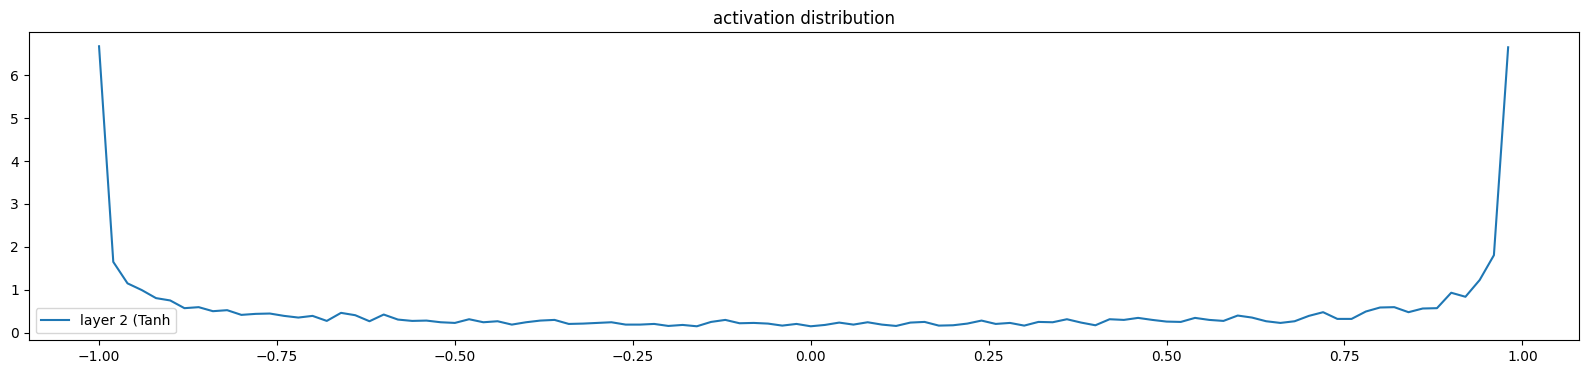

In [99]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 5.634243e-03


Text(0.5, 1.0, 'gradient distribution')

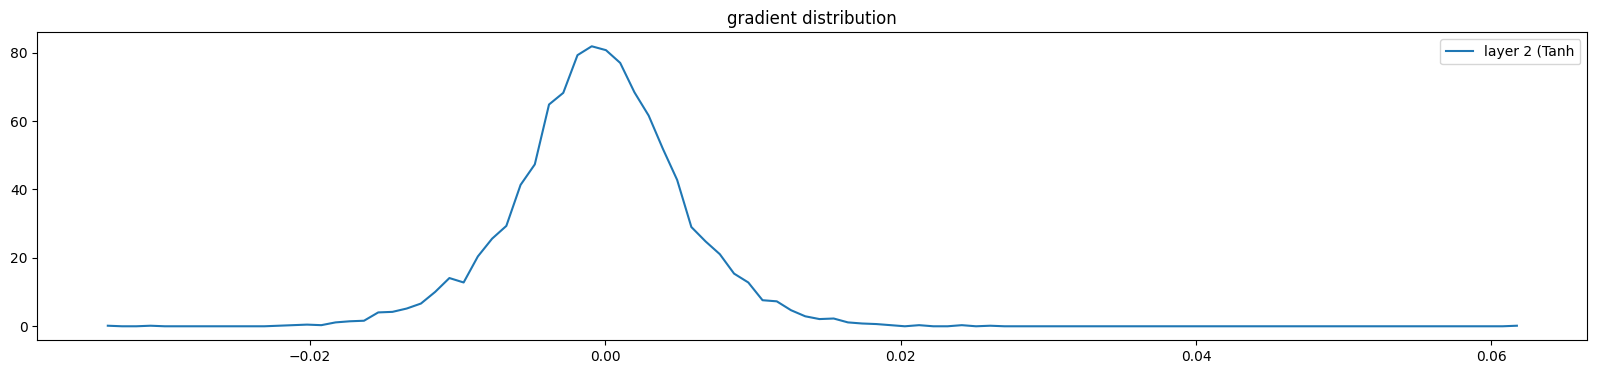

In [100]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

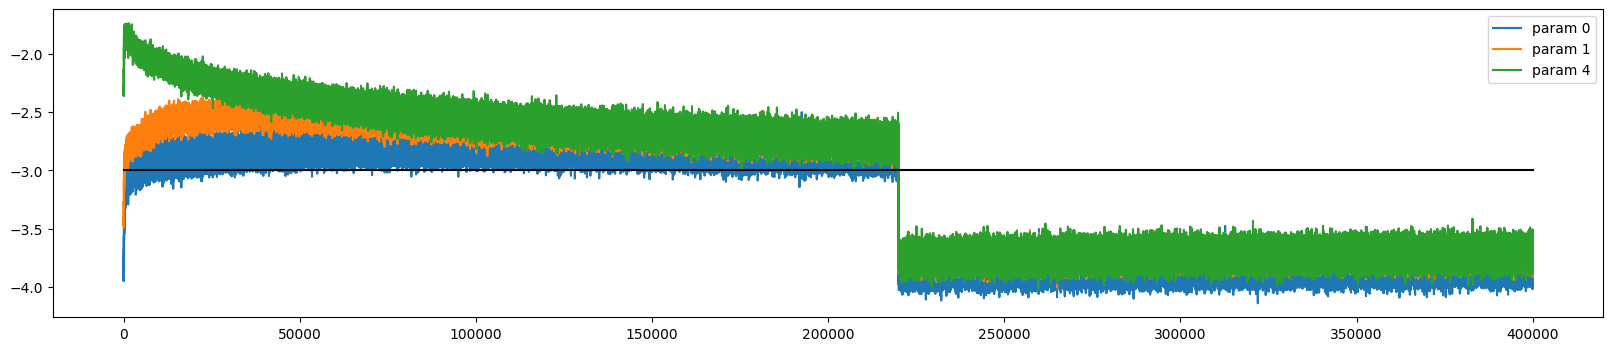

In [101]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [102]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 1.934093713760376
val 2.0359749794006348


In [103]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
amelia.
khylmri.
reylynn.
cassie.
mahnen.
deliyat.
kaeli.
nermarthceeigh.
kaleigh.
hamond.
jaquinn.
shoine.
livabi.
wattlo.
dearyn.
kai.
eveir.
demed.
ediia.


### <span style="color:red"> **Exercises (MLP)** </span>
### <section style="color:cyan"> E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that (1)  the network trains just fine  (2) the network doesn't train at all, but actually it is (3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly. </section>
##### 1. step 0: All the paramters are 0.
##### 2. step 1: Backpropagate once. Only b2 receives non zero gradient. The b2 gains some non uniformity.
##### 3. step 2: backpropagation is unable to go backward. So it becomes a stationary probability distribution irrespective of input.

### If the initialisation was symmetric that is equal at each layer then another problem arises. The flow of gradients will be like .The b2 s  change non uniformly but each b2 gradient flows to through every weight of each out layer uniformly. Therefor the output layer neurons will be a collection of same weights. Now these will make sure that every gradient flow to all the hidden layer neurons are same so it acts like a single neuron(the entire hidden layer).So there will be like a single neuron from the ebedding layer which learns in this case .The hidden layer neuron represents only a single feature depending on which the output is predicted


In [133]:
layers=[Linear(block_size*vector_dim,hidden_layer_size),Tanh(),Linear(hidden_layer_size,27)]
#the look-up table
C=torch.randn((27,vector_dim),generator=g)
layers[-1].weight*=0
layers[-1].bias*=0
layers[-3].weight*=0
layers[-3].bias*=0
parameters=  [C]+[p for layer in layers for p in layer.parameters()]
print("Total Parameters:",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True


Total Parameters: 15897


In [135]:
# same optimization as last time
max_steps = 300000
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 220000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 300000: 2.6091


layer 0 (    Linear): mean +0.00, std 0.00, saturated: 0.00%
layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 2 (    Linear): mean +0.00, std 1.14, saturated: 48.15%


Text(0.5, 1.0, 'activation distribution')

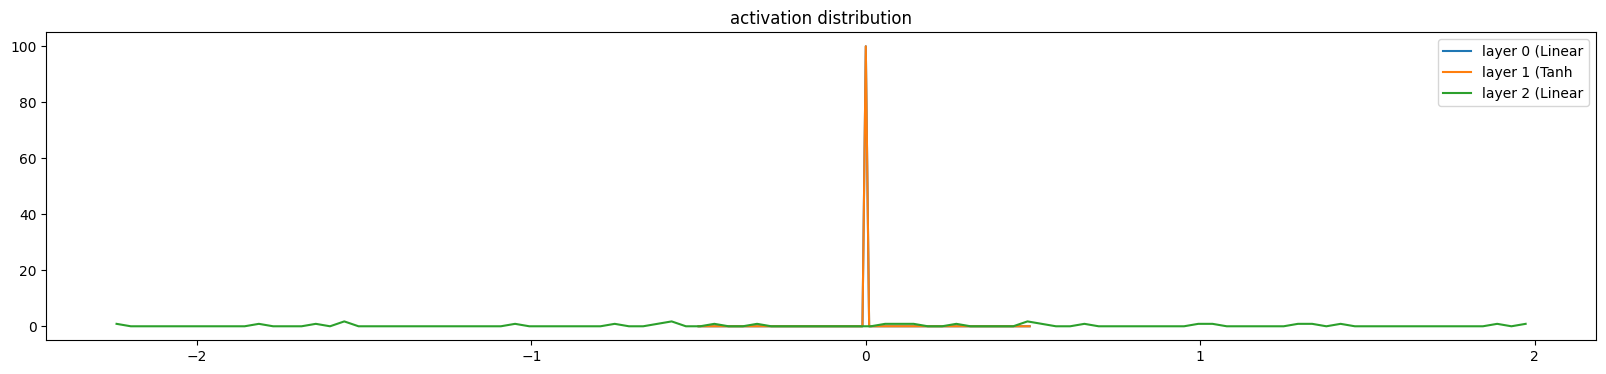

In [137]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers): # note: exclude the output layer
  if isinstance(layer,Linear) or isinstance(layer,Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 0 (    Linear): mean +0.000000, std 0.000000e+00
layer 1 (      Tanh): mean +0.000000, std 0.000000e+00
layer 2 (    Linear): mean -0.000000, std 5.664996e-03


Text(0.5, 1.0, 'gradient distribution')

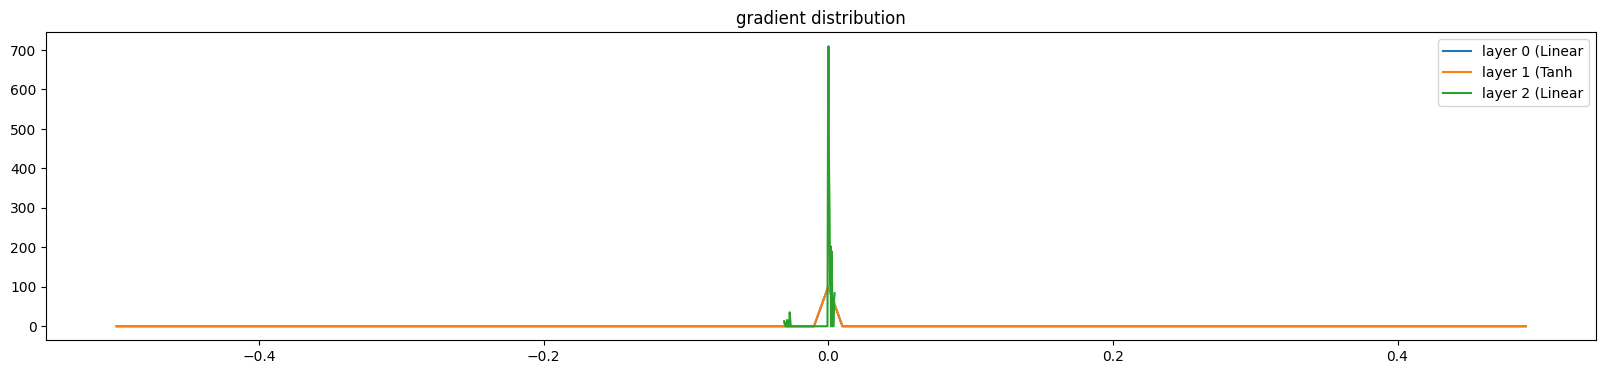

In [139]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers): # note: exclude the output layer
  #if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

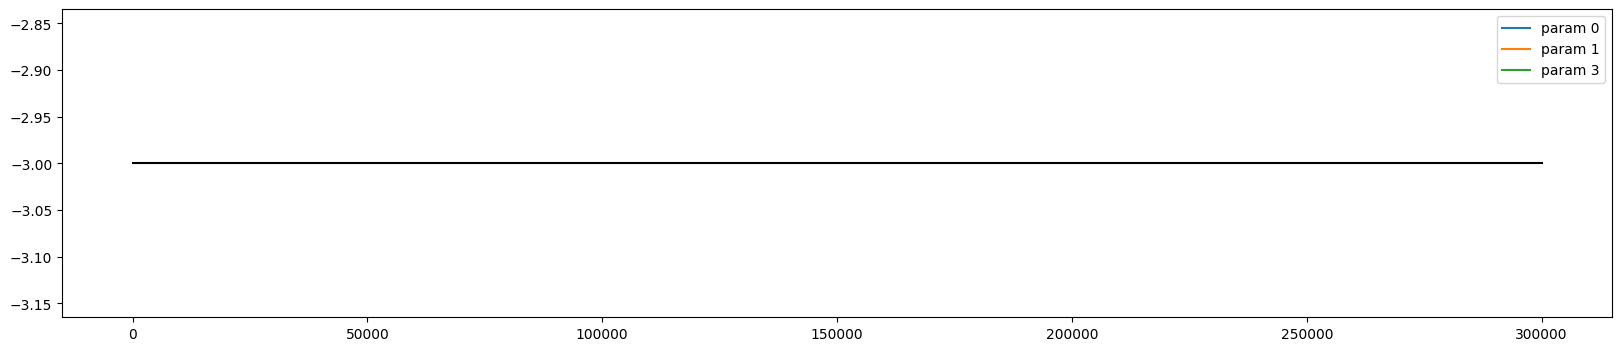

In [ ]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [140]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.8233799934387207
val 2.8218822479248047


In [141]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesahc.
iaeei.
.
ermaia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
qeijn.
s.
lilea.
.


### <section style="color:cyan"> E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool. </section>

In [166]:
#building the dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
train_data = datasets.MNIST(root="data",train=True,download=True,transform=ToTensor())
test_data=datasets.MNIST(root="data",train=False,download=True,transform=ToTensor())
Xtr=[]
Ytr=[]
Xte=[]
Yte=[]
for eg in train_data:
    Xtr.append(eg[0])
    Ytr.append(eg[1])
for eg in test_data:
    Xte.append(eg[0])
    Yte.append(eg[1])
Xtr=torch.stack(Xtr)
Ytr=torch.tensor(Ytr)
Xte=torch.stack(Xte)
Yte=torch.tensor(Yte)

In [167]:
Xte.view((-1,784)).shape

torch.Size([10000, 784])

In [168]:
layers=[Linear(784,512,bias=False),BatchNormld(512),Tanh(),
        Linear(512,256,bias=False),BatchNormld(256),Tanh(),
        Linear(256,10,bias=False),BatchNormld(10)]

with torch.no_grad():
    layers[-1].gamma*=0.1
    #apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*= 5/3
    layers[-2].weight*=0.6
        

parameters=[p for layer in layers for p in layer.parameters()]
print("Total Parameters:",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True


Total Parameters: 536596


In [169]:
# same optimization as last time
max_steps = 200000
mini_batch_size=32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (mini_batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  x = Xb.view(-1,784) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  with torch.no_grad():
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      x = Xte.view(-1,784)
      for layer in layers:
        x = layer(x)
      print('validation loss:',torch.nn.functional.cross_entropy(x,Yte).item())
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 2.2809
validation loss: 2.3016388416290283
  10000/ 200000: 0.0159
validation loss: 0.0726105198264122
  20000/ 200000: 0.0261
validation loss: 0.06490717828273773
  30000/ 200000: 0.0066
validation loss: 0.061004601418972015
  40000/ 200000: 0.0161
validation loss: 0.059985626488924026
  50000/ 200000: 0.0067
validation loss: 0.06538189947605133
  60000/ 200000: 0.0036
validation loss: 0.06164271757006645
  70000/ 200000: 0.0017
validation loss: 0.05248112976551056
  80000/ 200000: 0.0012
validation loss: 0.05783243477344513
  90000/ 200000: 0.0006
validation loss: 0.055568721145391464
 100000/ 200000: 0.0024
validation loss: 0.059121739119291306
 110000/ 200000: 0.0012
validation loss: 0.05615249648690224
 120000/ 200000: 0.0005
validation loss: 0.052928581833839417
 130000/ 200000: 0.0002
validation loss: 0.05366451293230057
 140000/ 200000: 0.0016
validation loss: 0.05469684302806854
 150000/ 200000: 0.0223
validation loss: 0.05538094416260719
 160000/ 200000: 0.00

layer 2 (      Tanh): mean -0.00, std 0.67, saturated: 8.54%
layer 5 (      Tanh): mean +0.00, std 0.70, saturated: 10.91%


Text(0.5, 1.0, 'activation distribution')

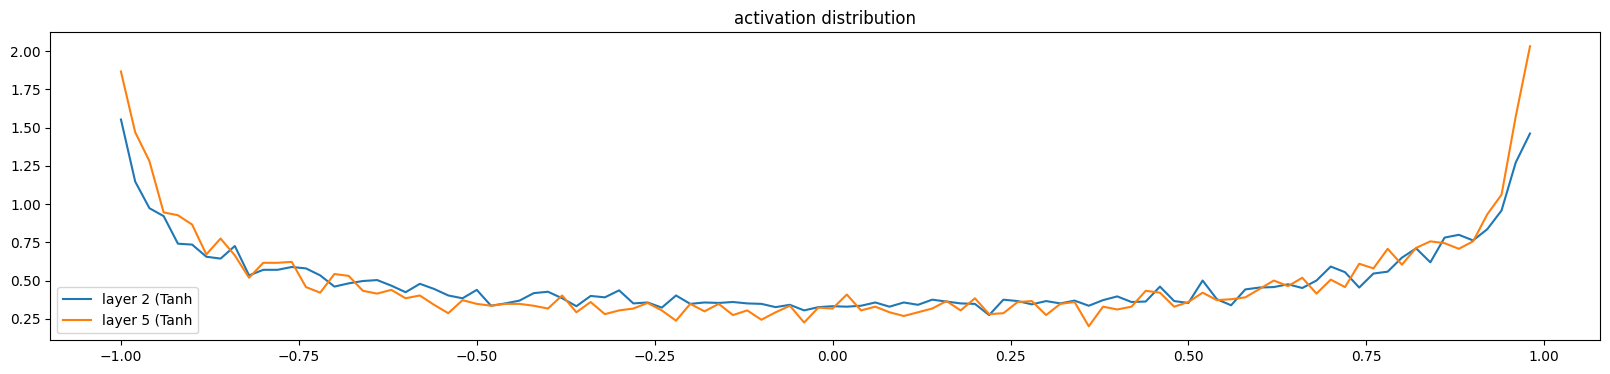

In [170]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 2.161963e-06
layer 5 (      Tanh): mean -0.000000, std 3.590181e-06


Text(0.5, 1.0, 'gradient distribution')

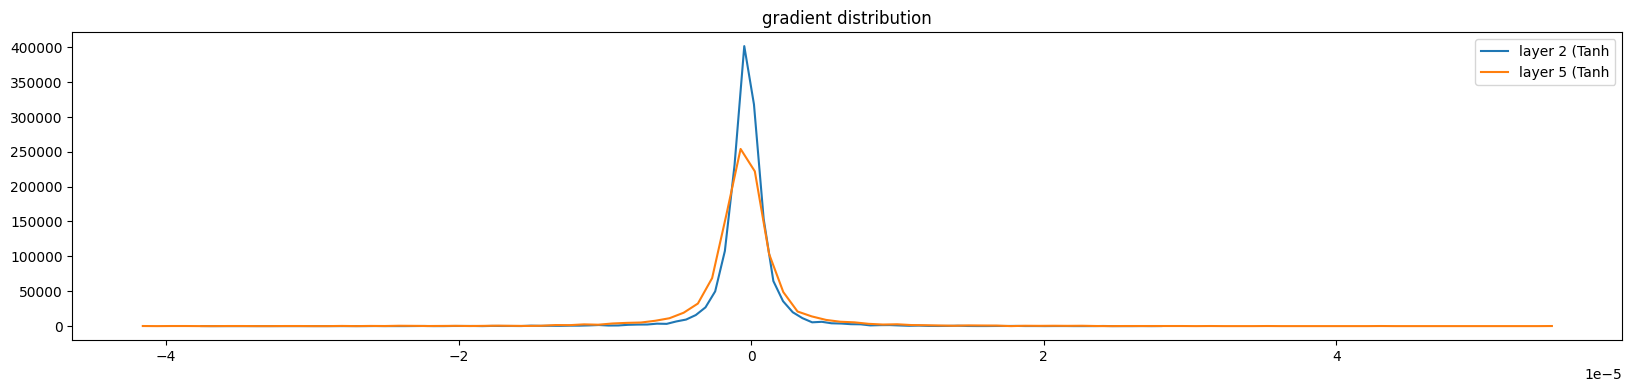

In [171]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

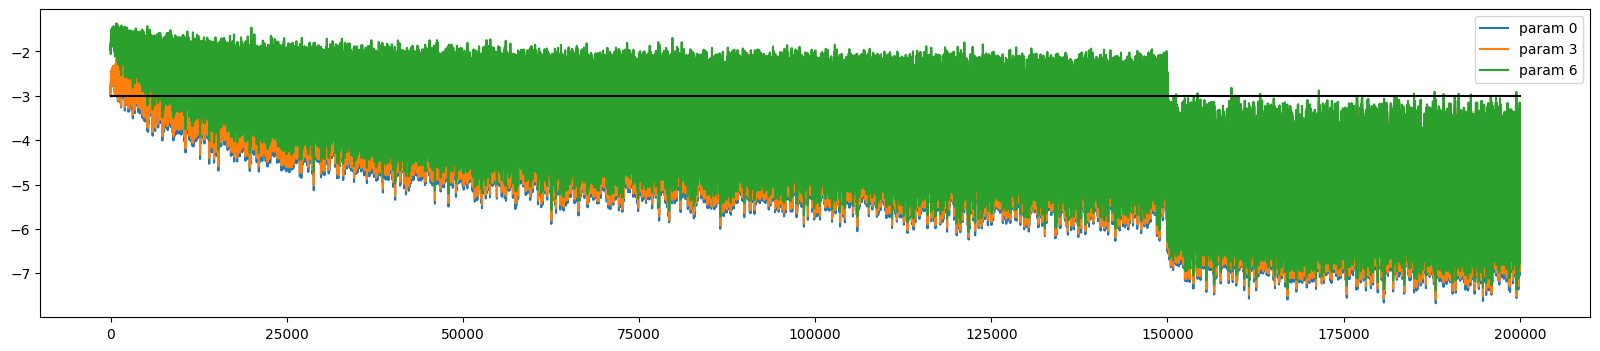

In [172]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [176]:
# Put BatchNorm layers into inference mode
for layer in layers:
    if isinstance(layer, BatchNormld):
        layer.training = False


# Build folded network


new_layers = []

i = 0
while i < len(layers):

    # Linear -> BatchNorm pair
    if (
        i + 1 < len(layers)
        and isinstance(layers[i], Linear)
        and isinstance(layers[i + 1], BatchNormld)
    ):

        linear = layers[i]
        bn = layers[i + 1]

        fan_in, fan_out = linear.weight.shape

        folded_linear = Linear(
            fan_in,
            fan_out,
            bias=True
        )

        with torch.no_grad():

            scale = bn.gamma / torch.sqrt(
                bn.running_var + bn.eps
            )

            folded_linear.weight = (
                linear.weight * scale
            )

            folded_linear.bias = (
                bn.beta
                - bn.running_mean * scale
            )

        new_layers.append(folded_linear)

        # skip the BN layer
        i += 2

    else:

        new_layers.append(layers[i])
        i += 1

# Forward helper

def forward(layer_list, x):

    for layer in layer_list:
        x = layer(x)

    return x


# Compare outputs

x = Xtr[:100].view(-1, 784)

old_out = forward(layers, x)
new_out = forward(new_layers, x)

print("allclose =", torch.allclose(old_out, new_out, atol=1e-5))
print("max diff =", (old_out - new_out).abs().max())

allclose = True
max diff = tensor(1.7166e-05, grad_fn=<MaxBackward1>)
